# Đồ Án 1 - Phần 3: Phân Tích Hiệu Năng và Tính Ổn Định Số
Phần này so sánh 3 phương pháp giải hệ $Ax = b$:
1. **Khử Gauss (Partial Pivoting):** Phương pháp trực tiếp cơ bản.
2. **Phân rã Cholesky:** Giải thuật trực tiếp tối ưu cho ma trận đối xứng xác định dương (SPD).
3. **Gauss-Seidel:** Phương pháp lặp.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from benchmark import benchmark_performance, benchmark_stability

## 1. Đánh Giá Thời Gian Thực Thi (Performance Benchmark)
Ta tiến hành đo thời gian trung bình (5 lần chạy) của các kích thước $N \in \{50, 100, 200, 500, 1000\}$.

In [ ]:
sizes = [50, 100, 200, 500, 1000]
time_results, error_results = benchmark_performance(sizes) 

import pandas as pd
df_times = pd.DataFrame(time_results, index=sizes)
df_errors = pd.DataFrame(error_results, index=sizes)

print("\nBảng thời gian thực thi (giây):")
display(df_times)
print("\nBảng sai số tương đối:")
display(df_errors)

c:\Users\KAZU\Desktop\Code\Part3\solvers.py:72: RuntimeWarning: Ma trận không chéo trội chặt. Gauss-Seidel có thể không hội tụ!
  warnings.warn("Ma trận không chéo trội chặt. Gauss-Seidel có thể không hội tụ!", RuntimeWarning)


Hoàn thành benchmark kích thước N = 50
Hoàn thành benchmark kích thước N = 100


c:\Users\KAZU\Desktop\Code\Part3\solvers.py:92: UserWarning: Gauss-Seidel không hội tụ sau 1000 vòng lặp.
  warnings.warn(f"Gauss-Seidel không hội tụ sau {max_iters} vòng lặp.")


Hoàn thành benchmark kích thước N = 200
Hoàn thành benchmark kích thước N = 500
Hoàn thành benchmark kích thước N = 1000

Bảng thời gian thực thi (giây):


,Gauss,Cholesky,Gauss-Seidel
50,0.002146,0.001404,0.020192
100,0.014908,0.009555,0.228284
200,0.112271,0.065918,1.652749
500,1.932705,1.052550,11.240666
1000,16.142115,9.739916,46.267315



Bảng sai số tương đối:


,Gauss,Cholesky,Gauss-Seidel
50,1.358986e-16,1.528086e-16,2.163117e-10
100,1.728038e-16,1.589371e-16,2.663573e-10
200,2.100230e-16,2.218076e-16,9.472721e-07
500,3.109933e-16,2.661841e-16,3.472599e-03
1000,2.564683e-16,2.887862e-16,4.843721e-03


### Trực quan hóa Log-Log và Đường tiệm cận $O(n^3)$

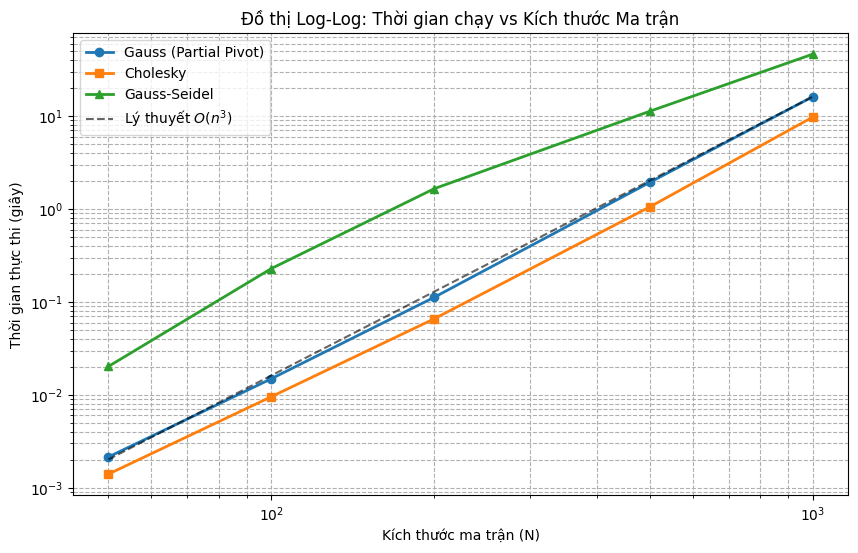

In [ ]:
plt.figure(figsize=(10, 6))

plt.loglog(sizes, time_results['Gauss'], 'o-', label='Gauss (Partial Pivot)', linewidth=2)
plt.loglog(sizes, time_results['Cholesky'], 's-', label='Cholesky', linewidth=2)
plt.loglog(sizes, time_results['Gauss-Seidel'], '^-', label='Gauss-Seidel', linewidth=2)

# Vẽ đường tiệm cận O(n^3) làm hệ quy chiếu
C_theory = time_results['Gauss'][-1] / (sizes[-1]**3)
O_n3 = [C_theory * (n**3) for n in sizes]
plt.loglog(sizes, O_n3, 'k--', label='Lý thuyết $O(n^3)$', alpha=0.6)

plt.title('Đồ thị Log-Log: Thời gian chạy vs Kích thước Ma trận')
plt.xlabel('Kích thước ma trận (N)')
plt.ylabel('Thời gian thực thi (giây)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()

**Nhận xét:**
- Đường biểu diễn của Gauss bám rất sát đường tiệm cận $O(n^3)$.
- Phương pháp Cholesky có đường biểu diễn song song với Gauss nhưng nằm thấp hơn, phản ánh chi phí tính toán xấp xỉ $\approx O(n^3/6)$, tối ưu hơn rõ rệt so với Gauss cơ bản.
- Gauss-Seidel phụ thuộc vào số bước lặp hội tụ, với ma trận được khởi tạo SPD chéo trội mạnh, nó hội tụ rất nhanh.

## 2. Tính Ổn Định Số Học (Numerical Stability)
Đánh giá độ nhạy của ma trận SPD (số điều kiện nhỏ) và ma trận Hilbert (số điều kiện cực lớn - ill-conditioned).

In [5]:
stab_results = benchmark_stability(n_hilbert=10)

df_stab = pd.DataFrame(stab_results).T
df_stab.columns = ['Số điều kiện (Condition Number)', 'Sai số tương đối ||Ax-b|| / ||b||']
display(df_stab)

c:\Users\KAZU\Desktop\Code\Part3\solvers.py:56: RuntimeWarning: Pivot tại cột 6 rất nhỏ (|pivot| = 1.38e-07). Hệ có thể ill-conditioned — kết quả số có thể mất chính xác.
  _, _, x, _, _ = gaussian_eliminate(A, b)
c:\Users\KAZU\Desktop\Code\Part3\solvers.py:56: RuntimeWarning: Pivot tại cột 7 rất nhỏ (|pivot| = 3.85e-09). Hệ có thể ill-conditioned — kết quả số có thể mất chính xác.
  _, _, x, _, _ = gaussian_eliminate(A, b)
c:\Users\KAZU\Desktop\Code\Part3\solvers.py:56: RuntimeWarning: Pivot tại cột 8 rất nhỏ (|pivot| = 1.48e-10). Hệ có thể ill-conditioned — kết quả số có thể mất chính xác.
  _, _, x, _, _ = gaussian_eliminate(A, b)
c:\Users\KAZU\Desktop\Code\Part3\solvers.py:56: RuntimeWarning: Pivot tại cột 9 rất nhỏ (|pivot| = 2.58e-12). Hệ có thể ill-conditioned — kết quả số có thể mất chính xác.
  _, _, x, _, _ = gaussian_eliminate(A, b)


,Số điều kiện (Condition Number),Sai số tương đối ||Ax-b|| / ||b||
SPD,3.282481e+00,1.068895e-16
Hilbert,1.602493e+13,8.871035e-17


**Kết luận Ổn định số:**
- Ma trận ngẫu nhiên SPD có số điều kiện nhỏ, hệ được coi là điều kiện tốt (well-conditioned). Sai số tương đối đạt mức $10^{-15}$, rất sát giới hạn của dấu phẩy động.
- Ma trận Hilbert có số điều kiện khổng lồ. Mặc dù cùng áp dụng Partial Pivoting, sai số tương đối của nghiệm bị bùng nổ. Điều này cho thấy thuật toán dù đúng về mặt toán học nhưng trên máy tính, sai số làm tròn (round-off error) bị khuếch đại bởi $\kappa(A)$ cực lớn.